# Getting started with Megamicros objects
® *Copyright Bimea 2024-2025*

The `Megamicros` class is the base class for all *Megamicros* usb antennas. 
This Notebook shows how you can use the `Megamicros` interface provided you have a *Megamicros* device connected on your USB port.

Beware that you need to have `libusb` installed, both the python interface and the C libusb.1.0.26 library

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt

from megamicros.log import log
from megamicros.antenna import Megamicros

# set log level to INFO to get more information (available levels are DEBUG, INFO, WARNING, ERROR, FATAL)
log.setLevel( "INFO" ) 

## Declare your antenna object

The ``Megamicros`` constructor needs no argument. The device is detected and the class device parameters are populated.

In [5]:
antenna = Megamicros()

2025-10-22 23:58:55,282 [INFO]:  .Connecting to USB device fe27:ac03 ...
2025-10-22 23:58:55,284 [INFO]:  .Claimed interface 0 on USB device fe27:ac03
2025-10-22 23:58:55,285 [INFO]:  .Released interface 0 on USB device fe27:ac03
2025-10-22 23:58:55,285 [INFO]:  .Connected on USB device fe27:ac03
2025-10-22 23:58:55,285 [INFO]:  .Performing selftest using bulk read method...
2025-10-22 23:58:55,286 [INFO]:  .Claimed interface 0 on USB device fe27:ac03
2025-10-22 23:58:55,651 [INFO]:  .Selftest completed successfully
2025-10-22 23:58:55,653 [INFO]:  .Released interface 0 on USB device fe27:ac03
2025-10-22 23:58:55,654 [INFO]:  .Autotest results:
2025-10-22 23:58:55,655 [INFO]:   > equivalent recording time is: 0.1 seconds
2025-10-22 23:58:55,656 [INFO]:   > Received 599760 data bytes: 4410 samples on 34 channels
2025-10-22 23:58:55,656 [INFO]:   > detected 8 active MEMs: [0, 1, 2, 3, 4, 5, 6, 7]
2025-10-22 23:58:55,657 [INFO]:   > detected no active analogs
2025-10-22 23:58:55,657 [INFO

Lets know some properties of the connected antenna:

In [6]:
print( "Available MEMS: ", antenna.available_mems )
print( "Available Analogs: ", antenna.available_analogs )

Available MEMS:  [0, 1, 2, 3, 4, 5, 6, 7]
Available Analogs:  []


Try 1s of acquisition on all available MEMs

In [7]:
antenna.setActiveMems( antenna.available_mems )
antenna.setActiveAnalogs( antenna.available_analogs )
antenna.setDuration( 1 )
antenna.run()
antenna.wait()

2025-10-22 23:58:55,675 [INFO]:  .Starting run execution on Megamicros device...
2025-10-22 23:58:55,675 [INFO]:   > Perform 1s run loop
2025-10-22 23:58:55,676 [INFO]:   > Sampling frequency: 50000 Hz
2025-10-22 23:58:55,676 [INFO]:   > FPGA clockdiv value: 9
2025-10-22 23:58:55,677 [INFO]:   > 8 activated microphones
2025-10-22 23:58:55,677 [INFO]:   > Activated microphones: [0, 1, 2, 3, 4, 5, 6, 7]
2025-10-22 23:58:55,678 [INFO]:   > MEMs sensibility: 3.54e-06
2025-10-22 23:58:55,678 [INFO]:   > 0 activated analogic channels
2025-10-22 23:58:55,679 [INFO]:   > Activated analogic channels: []
2025-10-22 23:58:55,679 [INFO]:   > Analogics sensibility: 0.33
2025-10-22 23:58:55,679 [INFO]:   > Whether counter is activated: YES
2025-10-22 23:58:55,680 [INFO]:   > Whether status is activated: NO
2025-10-22 23:58:55,681 [INFO]:   > Time activation (MEMS powering delay): 200 ms
2025-10-22 23:58:55,681 [INFO]:   > Total channels number is 9
2025-10-22 23:58:55,682 [INFO]:   > Datatype: int32

Getting data can be done by iterate through the `antenna` object provided the antenna had already received all the data:

In [8]:
# Print frames stored in the queue
print(f"queue content : {antenna.queue_content} frames")

# Retrieve data from the queue
for data in antenna:
    print( f"data={data}" )

queue content : 49 frames
data=[[ 10476  10477  10478 ...  11497  11498  11499]
 [ -1444  -1092  -1320 ...  -3378  -1490  -2666]
 [  4146  -1434   3108 ...    618  -3128    594]
 ...
 [ -6672 -14054  -8496 ... -15466  -6052 -11048]
 [ -6084  -3544  -7266 ...  -7286  -2948 -10924]
 [ -1216   -516   -242 ...  -3146  -1268    490]]
data=[[ 11500  11501  11502 ...  12521  12522  12523]
 [ -1818  -2252  -3444 ...  -2156  -1848  -2726]
 [ -1862   -182   -922 ...    964   2112    746]
 ...
 [-11258  -4802 -15590 ...  -7174  -2548  -7522]
 [  -196 -11996  -2022 ...  -1440  -5412   -850]
 [ -5578   4774  -6548 ...   3086  -5134   3414]]
data=[[12524 12525 12526 ... 13545 13546 13547]
 [-1568 -2632 -1954 ... -1340 -1808  -654]
 [ 2280  -194  2514 ...  1404  -482  3664]
 ...
 [-2262 -6242 -4080 ...  3518 -3992  3840]
 [-4004 -1658 -3554 ...  -610 -1642   338]
 [-3468   330  1258 ... -3100   266 -2430]]
data=[[13548 13549 13550 ... 14569 14570 14571]
 [-1790  -874 -1618 ...   228  -616  -102]
 [-1

Once the frames have been retrieved, the queue is empty:

In [9]:
# Print frames stored in the queue
print(f"queue content : {antenna.queue_content} frames")

queue content : 0 frames


You can force some MEMs to be available while they actually are not. 
Corresponding channels will stay at 0:

In [10]:
antenna.setAvailableMems( [i for i in range(32)] )
print( "Available MEMS after setAvailableMems: ", antenna.available_mems )

antenna.run()
antenna.wait()

# Print frames stored in the queue
print(f"queue content : {antenna.queue_content} frames")

# Retrieve data from the queue
for data in antenna:
    print( f"data={data}" )

2025-10-22 23:58:59,001 [INFO]:  .Starting run execution on Megamicros device...
2025-10-22 23:58:59,002 [INFO]:   > Perform 1s run loop
2025-10-22 23:58:59,003 [INFO]:   > Sampling frequency: 50000 Hz
2025-10-22 23:58:59,003 [INFO]:   > FPGA clockdiv value: 9
2025-10-22 23:58:59,004 [INFO]:   > 8 activated microphones
2025-10-22 23:58:59,004 [INFO]:   > Activated microphones: [0, 1, 2, 3, 4, 5, 6, 7]
2025-10-22 23:58:59,005 [INFO]:   > MEMs sensibility: 3.54e-06
2025-10-22 23:58:59,005 [INFO]:   > 0 activated analogic channels
2025-10-22 23:58:59,005 [INFO]:   > Activated analogic channels: []
2025-10-22 23:58:59,005 [INFO]:   > Analogics sensibility: 0.33
2025-10-22 23:58:59,006 [INFO]:   > Whether counter is activated: YES
2025-10-22 23:58:59,006 [INFO]:   > Whether status is activated: NO
2025-10-22 23:58:59,006 [INFO]:   > Time activation (MEMS powering delay): 200 ms
2025-10-22 23:58:59,007 [INFO]:   > Total channels number is 9
2025-10-22 23:58:59,007 [INFO]:   > Datatype: int32

Available MEMS after setAvailableMems:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


2025-10-22 23:58:59,278 [INFO]:  .Init asynchronous bulk transfer...
2025-10-22 23:58:59,280 [INFO]:  .Transfer thread execution started
2025-10-22 23:59:00,280 [INFO]:  .Thread timer ended: stop the bulk transfer...
2025-10-22 23:59:00,289 [INFO]:  .Quitting transfer loop due to end of process request...
2025-10-22 23:59:00,291 [INFO]:  .Released interface 0 on USB device fe27:ac03
2025-10-22 23:59:00,291 [INFO]:  .Megamicros acquisition process successfully ended


queue content : 49 frames
data=[[ 10264  10265  10266 ...  11285  11286  11287]
 [ -7042  -2084  -6998 ...  -3538  -1998  -3326]
 [  -864  -1040    594 ...    272    822   2174]
 ...
 [-16472  -6552 -15378 ...  -3872  -7060  -7984]
 [ -8534  -5266 -11936 ...  -4034  -4502  -3770]
 [ -5266   2642  -1734 ...     36  -3490  -2628]]
data=[[ 11288  11289  11290 ...  12309  12310  12311]
 [ -2090  -3538  -3176 ...  -3680  -3906  -3626]
 [   878   3224    146 ...  -1802  -2752  -1590]
 ...
 [ -3896 -10814  -4178 ...  -5694  -7482  -4328]
 [ -5180  -3954  -4802 ...  -4240  -5326  -4530]
 [   746  -5320   1980 ...   1738   -700   1334]]
data=[[12312 12313 12314 ... 13333 13334 13335]
 [-3744 -2754 -3670 ... -1268  -984 -1352]
 [-2994 -2028 -3136 ...   988  1494   798]
 ...
 [-6978 -5332 -6582 ... -2026 -3946 -3636]
 [-5122 -4702 -3808 ... -3186 -1366 -3088]
 [-1118   526  1052 ...  1178 -1112  -386]]
data=[[13336 13337 13338 ... 14357 14358 14359]
 [-1340 -1554 -1578 ... -2516 -2294 -2132]
 [ 1

Settings can be passed to the run() method as well:

In [11]:
antenna.run(
    duration=1,                             # acquisition time in seconds 
    mems = antenna.available_mems,          # activate all available MEMs
    counter = False,                        # do not get counter channel
    status = False,                         # do not get status channel
    datatype = 'int32',                     # set datatype to ìnt32 (default)
    sampling_frequency=50000                # set sampling frequency to 50kHz
)

antenna.wait()

2025-10-22 23:59:02,307 [INFO]:  .Starting run execution on Megamicros device...
2025-10-22 23:59:02,308 [INFO]:   > Perform 1s run loop
2025-10-22 23:59:02,309 [INFO]:   > Sampling frequency: 50000 Hz
2025-10-22 23:59:02,309 [INFO]:   > FPGA clockdiv value: 9
2025-10-22 23:59:02,310 [INFO]:   > 32 activated microphones
2025-10-22 23:59:02,310 [INFO]:   > Activated microphones: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
2025-10-22 23:59:02,311 [INFO]:   > MEMs sensibility: 3.54e-06
2025-10-22 23:59:02,311 [INFO]:   > 0 activated analogic channels
2025-10-22 23:59:02,312 [INFO]:   > Activated analogic channels: []
2025-10-22 23:59:02,312 [INFO]:   > Analogics sensibility: 0.33
2025-10-22 23:59:02,312 [INFO]:   > Whether counter is activated: NO
2025-10-22 23:59:02,312 [INFO]:   > Whether status is activated: NO
2025-10-22 23:59:02,313 [INFO]:   > Time activation (MEMS powering delay): 200 ms
2025-10-22 23:59:02,

In [12]:
# Only set MEMS 0 and 10. All previous args remain the same:
antenna.run( 
    mems = [0, 10],
)

antenna.wait()

2025-10-22 23:59:03,632 [INFO]:  .Starting run execution on Megamicros device...
2025-10-22 23:59:03,633 [INFO]:   > Perform 1s run loop
2025-10-22 23:59:03,634 [INFO]:   > Sampling frequency: 50000 Hz
2025-10-22 23:59:03,635 [INFO]:   > FPGA clockdiv value: 9
2025-10-22 23:59:03,636 [INFO]:   > 2 activated microphones
2025-10-22 23:59:03,637 [INFO]:   > Activated microphones: [0, 10]
2025-10-22 23:59:03,638 [INFO]:   > MEMs sensibility: 3.54e-06
2025-10-22 23:59:03,638 [INFO]:   > 0 activated analogic channels
2025-10-22 23:59:03,639 [INFO]:   > Activated analogic channels: []
2025-10-22 23:59:03,639 [INFO]:   > Analogics sensibility: 0.33
2025-10-22 23:59:03,639 [INFO]:   > Whether counter is activated: NO
2025-10-22 23:59:03,640 [INFO]:   > Whether status is activated: NO
2025-10-22 23:59:03,640 [INFO]:   > Time activation (MEMS powering delay): 200 ms
2025-10-22 23:59:03,640 [INFO]:   > Total channels number is 2
2025-10-22 23:59:03,641 [INFO]:   > Datatype: int32
2025-10-22 23:59:

The previous method suggests that real time is not possible.
Actually, you can perform real time acqusition if you iterate before calling the `wait` method, just after the `run` call. 
The important point is that the `run()` call is a non-blocking. As such it implies that the `wait()` method is mandatory and must not be forgotten: 

In [13]:
log.setLevel( "WARNING" ) 

antenna.run( 
    duration=1,       # acquisition time in seconds
    mems=[0, 1],      # activate only MEMs 0 and 1
    counter=True,     # get counter channel 
)

# Get only the counter (first channel)
counter = []
for data in antenna:
    counter.append(int(data[0][0]))

antenna.wait()

print( f"Counter values: {counter}" )

Counter values: [10363, 11387, 12411, 13435, 14459, 15483, 16507, 17531, 18555, 19579, 20603, 21627, 22651, 23675, 24699, 25723, 26747, 27771, 28795, 29819, 30843, 31867, 32891, 33915, 34939, 35963, 36987, 38011, 39035, 40059, 41083, 42107, 43131, 44155, 45179, 46203, 47227, 48251, 49275, 50299, 51323, 52347, 53371, 54395, 55419, 56443, 57467, 58491, 59515]


Let us measure the acquisition time: 

In [14]:
start_time = time.time()
antenna.run( 
    duration=1,       # acquisition time in seconds
    mems=[0, 1],      # activate only MEMs 0 and 1
    counter=True,     # get counter channel 
)
# Get only the counter (first channel)
counter = []
for data in antenna:
    counter.append(int(data[0][0]))
antenna.wait()
end_time = time.time()

print(f"Acquisition time: {end_time - start_time} seconds")

Acquisition time: 3.2937588691711426 seconds


Note that the elapsed time reaches 3.2 seconds, whereas the requested acquisition time was 1 second.

The method, as reported above, includes, in addition to the acquisition time (1s):
* The MEMs initialization delay (MEMs powering), default is 200 millisecond
* The timeout delay to leave the queue (2 seconds)
As a consequence, the total elapsed is 3.2 secondes.

In the next example we decide to supress the MEMS powering delay by setting to 0 the `time_activation` setting:


Acquisition time: 3.087661027908325 seconds


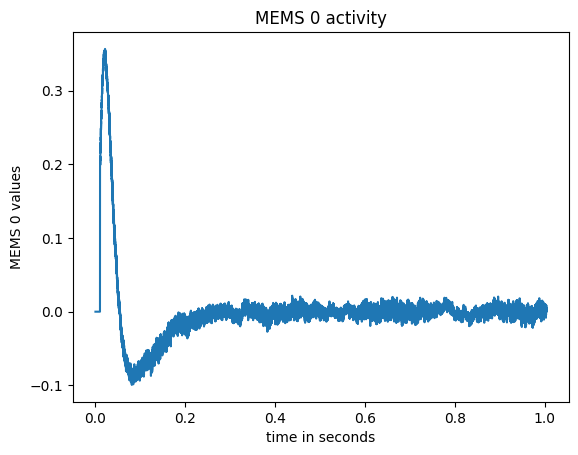

Counter values: [  264   265   266 ... 50437 50438 50439]


In [15]:
log.setLevel( "WARNING" ) 
import time
start_time = time.time()

antenna.run( 
    duration=1,       # acquisition time in seconds
    mems=[0, 1],      # activate only MEMs 0 and 1
    counter=True,     # get counter channel
    time_activation=0 # no delay for MEMs powering
)

# Get only the counter (first channel) and the MEMS 0 data (second channel)
counter = np.array( [] )
mems_0 = np.array( [] )
for data in antenna:
    counter = np.append(counter.astype(int), data[0][:])    # Counter data
    mems_0 = np.append(mems_0.astype(float), data[1][:])      # MEMS 0 data
antenna.wait()
end_time = time.time()

print(f"Acquisition time: {end_time - start_time} seconds")

t = np.array( range( len(mems_0) ) )/antenna.sampling_frequency
signal = mems_0 * antenna.mems_sensibility

# Plot mems_0:
plt.figure()
plt.plot( t, signal )
plt.title('MEMS 0 activity')
plt.xlabel('time in seconds')
plt.ylabel('MEMS 0 values')
plt.show()

print( f"Counter values: {counter}" )

You can see during the first 200ms start of the signal a transitory state which correspond to the MEMS powering. 
The values of the counter variable are lower because we are very close to the start of acquisition.

## Analog channels

If you have a Megamicros system that embed analog inputs, all you have to do is to declare them if you want to get thos signals:


In [16]:
print( f"Available analog channels = {antenna.available_analogs}" )

antenna.run( 
    duration=1, 
    mems = [0, 1],
    analogs = [0, 1],
    counter=False, 
    status=False,
    datatype = 'int32',
    sampling_frequency=50000
)

# Wait until the thread terminates
antenna.wait()

Available analog channels = []
